# **📊 Olist E-Ticaret Veri Analizi**

**Hazırlayan:** Tuğçe Yanar  



**İş Problemi:** Bu projede Brezilya'nın en büyük e-ticaret platformlarından biri olan Olist'in satış, teslimat ve müşteri verileri analiz edilerek müşteri davranışları, operasyonel performans ve müşteri memnuniyeti incelenmiştir.

## **🎯 Proje Amacı**

Bu projede Brezilya e-ticaret veri seti analiz edilerek:

- Sipariş davranışları incelenecek
- Teslimat süresi analiz edilecek
- Müşteri memnuniyeti değerlendirilecek
- Ödeme yöntemleri incelenecek
- Hipotez testi uygulanacaktır


## **📁 Veri Seti**

Kullanılan tablolar:

- customers
- orders
- order_items
- payments
- reviews
- products
- sellers


In [ ]:
import pandas as pd
import plotly.express as px

In [ ]:
customers = pd.read_csv("customers.csv")
orders = pd.read_csv("orders.csv")
order_items = pd.read_csv("order_items.csv")
payments = pd.read_csv("payments.csv")
reviews = pd.read_csv("reviews.csv")
products = pd.read_csv("products.csv")
sellers = pd.read_csv("sellers.csv")

***SATIR SAYISI KONTROLÜ***

In [ ]:
print("customers:", customers.shape)
print("orders:", orders.shape)
print("order_items:", order_items.shape)
print("payments:", payments.shape)
print("reviews:", reviews.shape)
print("products:", products.shape)
print("sellers:", sellers.shape)

customers: (99441, 5)
orders: (99441, 8)
order_items: (112650, 7)
payments: (103886, 5)
reviews: (99224, 7)
products: (32951, 9)
sellers: (3095, 4)



*  İtems satır sayısının orders satır sayısından yüksek olması ▶  Bir siparişte birden fazla ürün bulunması demektir.

*  Reviews satır sayısının orders satır sayısından küçük olması ▶ Her sipariş yorum almamış demektir.







### ***NULL DEĞER KONTROLÜ***



customers → *null yok*

order_items → *null yok*

payments → *null yok*

sellers → *null yok*

In [ ]:
orders.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0



*   Sipariş iptali ve ödemenin başarısız olması
*   Teslim edilmeyen veya iade edilen siparişler
*   Lojistik süreci tamamlanmayan siparişler sebebiyle null değerler bulunuyor.


Teslimat süresi analizinde yalnızca teslim edilmiş siparişler kullanılacaktır.

***order_delivered_customer_date*** *null olan kayıtlar teslimat analizi dışında bırakılacaktır.* *Teslimat süresi hesaplanırken filtre uygulanacak.*





In [ ]:
reviews.isnull().sum()

,0
review_id,0
order_id,0
review_score,0
review_comment_title,87656
review_comment_message,58247
review_creation_date,0
review_answer_timestamp,0


Review_score için null değer yok, ancak metin yorumlarında null değerler oldukça fazla. Her müşteri yorum yazmak zorunda olmadığından normal bir durum.

*Müşteri memnuniyeti analizinde **review_score** kullanılacaktır.*

In [ ]:
products.isnull().sum()

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


**32.951** ürün içerisinden **610** adet ürünün kategori bilgisi eksik.
Null oranı **%1,8** olduğundan bu değerler drop edilmemiştir.

*Veri* *kaybı yaşamamak adına* ***'unknown'*** *olarak* *etiketlenmiştir*.

In [ ]:
products['product_category_name'].fillna("unknown", inplace=True)

/tmp/ipykernel_2350/2520141795.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  products['product_category_name'].fillna("unknown", inplace=True)


*  Name, description, photos bilgileri temel analizi etkilmeyeceğinden dokunulmamıştır.
*  2 adet ölçü null değerleri drop edilmiştir.

In [ ]:
products = products.dropna(subset = [
   "product_weight_g",
   "product_length_cm",
   "product_height_cm",
   "product_width_cm"
])

### ***VERİ TİPİ KONTROLÜ***

In [ ]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


*Tarih alanları datetime'a* *çevrildi*.

In [ ]:
orders[[
 "order_purchase_timestamp",
 "order_approved_at",
 "order_delivered_carrier_date",
 "order_delivered_customer_date",
 "order_estimated_delivery_date"
]] = orders[[
 "order_purchase_timestamp",
 "order_approved_at",
 "order_delivered_carrier_date",
 "order_delivered_customer_date",
 "order_estimated_delivery_date"
]].apply(pd.to_datetime)

In [ ]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [ ]:
order_items['shipping_limit_date'] = pd.to_datetime(order_items['shipping_limit_date'])

In [ ]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [ ]:
reviews['review_creation_date'] = pd.to_datetime(reviews['review_creation_date'])
reviews['review_answer_timestamp'] = pd.to_datetime(reviews['review_answer_timestamp'])

# ***Sipariş Fiyatı İstatistikleri***

Sipariş fiyatı için order_items tablosu kullanılmıştır. Kargo ücreti ve fiyatın toplamı baz alınmıştır.



In [ ]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


Sipariş bazlı analiz için order_id değerleri gruplanacak.

In [ ]:
order_totals = order_items.groupby("order_id")[["price","freight_value"]].sum()

In [ ]:
order_totals["order_total"] = order_totals["price"] + order_totals["freight_value"]

In [ ]:
order_totals.head()

,price,freight_value,order_total
order_id,,,
00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29,72.19
00018f77f2f0320c557190d7a144bdd3,239.90,19.93,259.83
000229ec398224ef6ca0657da4fc703e,199.00,17.87,216.87
00024acbcdf0a6daa1e931b038114c75,12.99,12.79,25.78
00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14,218.04


In [ ]:
order_totals.sort_values(by="order_total", ascending=False).head(10)

,price,freight_value,order_total
order_id,,,
03caa2c082116e1d31e67e9ae3700499,13440.0,224.08,13664.08
736e1922ae60d0d6a89247b851902527,7160.0,114.88,7274.88
0812eb902a67711a1cb742b3cdaa65ae,6735.0,194.31,6929.31
fefacc66af859508bf1a7934eab1e97f,6729.0,193.21,6922.21
f5136e38d1a14a4dbd87dff67da82701,6499.0,227.66,6726.66
2cc9089445046817a7539d90805e6e5a,5934.6,146.94,6081.54
a96610ab360d42a2e5335a3998b4718a,4799.0,151.34,4950.34
b4c4b76c642808cbe472a32b86cddc95,4599.9,209.54,4809.44
199af31afc78c699f0dbf71fb178d4d4,4690.0,74.34,4764.34


In [ ]:
order_totals["order_total"].describe()

,order_total
count,98666.000000
mean,160.577638
std,220.466087
min,9.590000
25%,61.980000
50%,105.290000
75%,176.870000
max,13664.080000


In [ ]:
high_orders= (order_totals["order_total"] > 1000).sum()
high_orders

np.int64(1148)

*1000 TL üzeri sipariş sayısı* ***1148***


*   Sipariş tutarlarının ortalaması 160 iken medyan 105’tir.
Ortalama medyandan yüksektir.
Bu durum veri setinde yüksek tutarlı uç siparişlerin bulunduğunu ve dağılımın sağa çarpık olduğunu göstermektedir.
*   Standart sapmanın da medyandan oldukça yüksek olması homojen bir dağılım olmadığı ve farklı segmentlerde harcamaların olduğunu göstermektedir.
*   Siparişlerin %75'i 176,87'nin altında harcamalar yapmış.
*   Bu durumda; müşterilerin  çoğu için orta-küçük tutarlı sipariş vermekte diyebiliriz. Yüksek sipariş tutarlı müşteri ise az sayıdadır.




***Sipariş Tutarı Dağılımı (Histogram)***

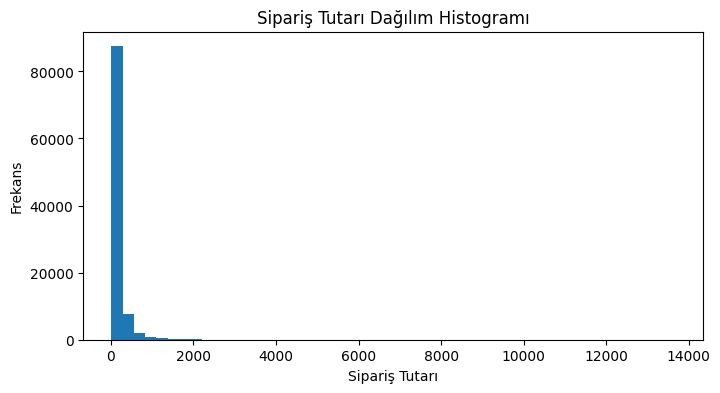

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.hist(order_totals["order_total"], bins=50)
plt.title("Sipariş Tutarı Dağılım Histogramı")
plt.xlabel("Sipariş Tutarı")
plt.ylabel("Frekans")
plt.show()

***Sipariş Tutarı Dağılımı (Kutu Grafiği)***

<function matplotlib.pyplot.show(close=None, block=None)>

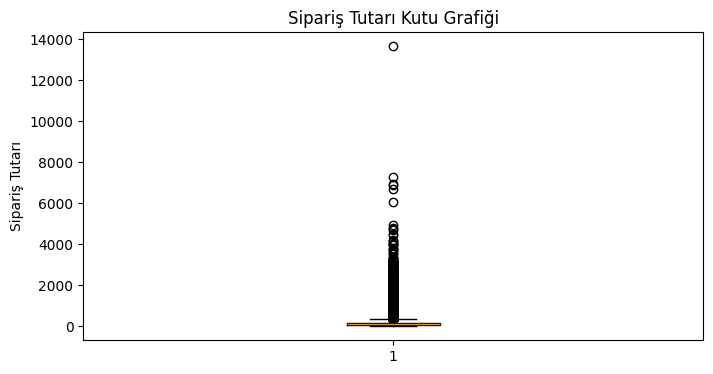

In [ ]:
plt.figure(figsize=(8,4))
plt.boxplot(order_totals["order_total"])
plt.title("Sipariş Tutarı Kutu Grafiği")
plt.ylabel("Sipariş Tutarı")
plt.show

Veri setinde aykırı değerler olduğundan grafikler sağlıklı sonuçlar üretmiyor;

**Aykırı değerler tespit edilip analize dahil edilmeyecek.**

In [ ]:
Q1 = order_totals["order_total"].quantile(0.25)
Q3 = order_totals["order_total"].quantile(0.75)

IQR = Q3-Q1

upper_limit =Q3 + IQR * 1.5

outliers = order_totals[order_totals["order_total"] > upper_limit ]
print("Upper_limit:", upper_limit)
print("Outlier sayısı:", len(outliers))


Upper_limit: 349.20500000000004
Outlier sayısı: 7775


Aykırı değerli olanları drop etmek yerine ayrı bir dataframe şeklinde tuttuk.



In [ ]:
clean_orders = order_totals[order_totals["order_total"] <= upper_limit]
outlier_orders = order_totals[order_totals["order_total"] > upper_limit]

print("Toplam veri sayısı:", len(order_totals))
print("Clean veri sayısı:", len(clean_orders))
print("Outlier veri sayısı:", len(outlier_orders))

Toplam veri sayısı: 98666
Clean veri sayısı: 90891
Outlier veri sayısı: 7775


In [ ]:
clean_orders["order_total"].describe()

,order_total
count,90891.000000
mean,115.266263
std,72.436836
min,9.590000
25%,58.630000
50%,97.200000
75%,155.730000
max,349.190000


***Sipariş Tutarı Dağılımı (Histogram)***

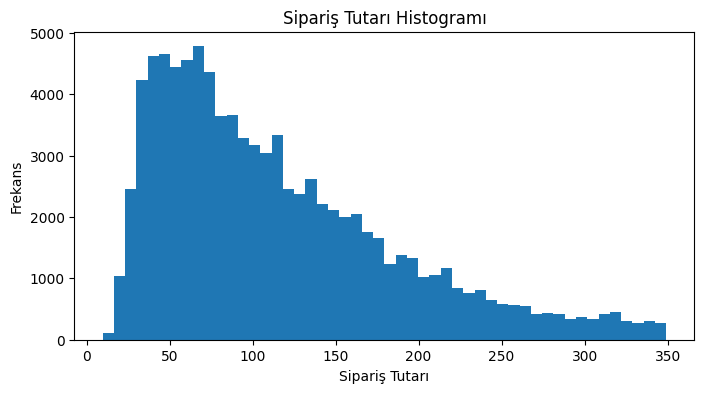

In [ ]:
plt.figure(figsize= (8,4))
plt.hist(clean_orders['order_total'], bins=50)
plt.title("Sipariş Tutarı Histogramı")
plt.xlabel("Sipariş Tutarı")
plt.ylabel("Frekans")
plt.show()

*  Aykırı değerler çıkarıldıktan sonra da grafik sağa çarpıktır.
*  Siparişlerin büyük çoğunluğu 50-100 TL bandındaki siparişler olup küçük-orta segment ağırlıklıdır.

***Sipariş Tutarı Dağılımı (Kutu Grafiği)***

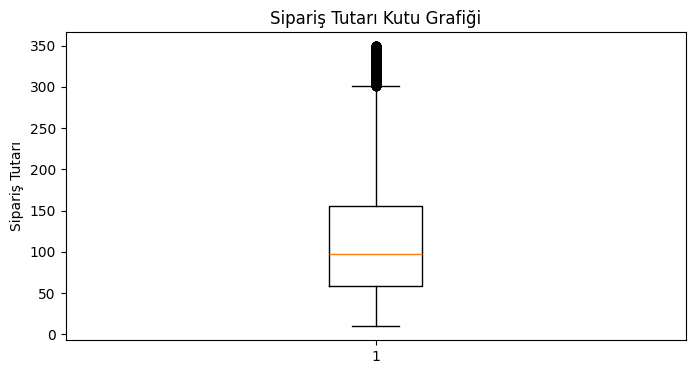

In [ ]:
plt.figure(figsize=(8,4))
plt.boxplot(clean_orders['order_total'])
plt.title("Sipariş Tutarı Kutu Grafiği")
plt.ylabel("Sipariş Tutarı")
plt.show()

*   Kutu alt bölgede yoğun → Siparişlerin çoğu düşük tutarlı.
*   Üst bıyık daha uzun → Dağılım sağa çarpık.



***Neler Yapılabilir?***
*   100 TL ve üzeri için ücretsiz kargo veya 10 TL indirim kampanyası yapılabilir.
*   100 TL'den sonra ciddi bir düşüş var. İnsanlar tekil ürün alıp çıkıyor olabilir.İkili,üçlü paketler oluşturup sepetlere yan ürünler ekleyerek tekil alımlar çoklulara çevrilebilir.
*   VIP müşterilere bir sadakat programı uygulabilir.


# ***Ürün Kategorisi Dağılımı***

order_items tablosunda kategori bilgisi yok. Bu sebeple;

***order_items*** ve ve ***products*** tabloları merge edilecek, ***order_items_product*** adında yeni df oluşturulacak.

In [ ]:
order_items_products = order_items.merge(products, on = "product_id", how = "left")

In [ ]:
order_items_products.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0


In [ ]:
category_counts = order_items_products["product_category_name"].value_counts()

In [ ]:
category_counts.count()

np.int64(74)

In [ ]:
translation_tr = {
    "cama_mesa_banho": "Yatak, Banyo ve Ev Tekstili",
    "beleza_saude": "Güzellik ve Sağlık",
    "esporte_lazer": "Spor ve Outdoor",
    "moveis_decoracao": "Mobilya ve Dekorasyon",
    "informatica_acessorios": "Bilgisayar ve Aksesuar",
    "utilidades_domesticas": "Ev Gereçleri",
    "relogios_presentes": "Saat ve Hediyelik",
    "telefonia": "Telefon",
    "ferramentas_jardim": "Bahçe ve Aletler",
    "automotivo": "Otomotiv"
}

In [ ]:
category_counts_tr = category_counts.copy()
category_counts_tr.index = category_counts_tr.index.map(translation_tr)

In [ ]:
top10_categories_tr = category_counts_tr.head(10)
top10_categories_tr

,count
product_category_name,
"Yatak, Banyo ve Ev Tekstili",11115
Güzellik ve Sağlık,9670
Spor ve Outdoor,8641
Mobilya ve Dekorasyon,8334
Bilgisayar ve Aksesuar,7827
Ev Gereçleri,6964
Saat ve Hediyelik,5991
Telefon,4545
Bahçe ve Aletler,4347


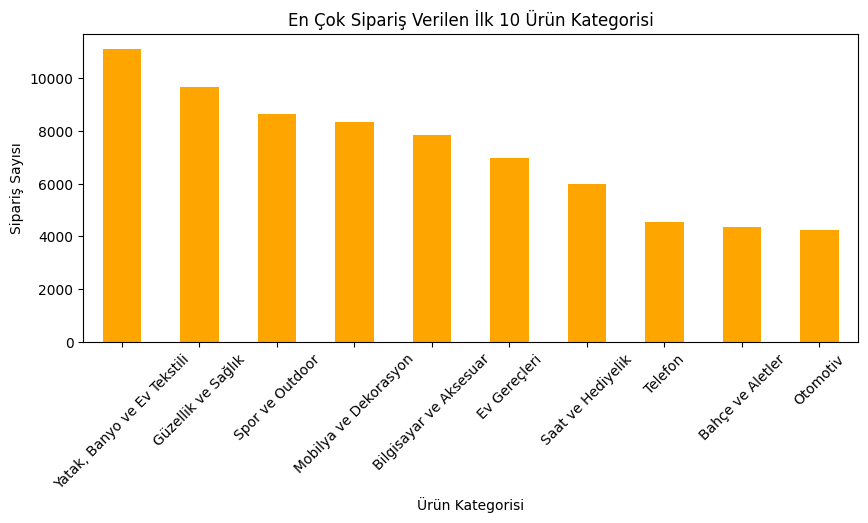

In [ ]:
plt.figure(figsize=(10,4))
top10_categories_tr.plot(kind="bar", color="orange")
plt.title("En Çok Sipariş Verilen İlk 10 Ürün Kategorisi")
plt.xlabel("Ürün Kategorisi")
plt.ylabel("Sipariş Sayısı")
plt.xticks(rotation=45)
plt.show()


*   Veri setinde siparişler tüm kategorilere eşit dağılmamıştır
*   Müşteri talebinin ağırlıklı olarak ev, kişisel bakım ve günlük yaşam ürünlerinde yoğunlaştığı görülmektedir.
- En çok talep gören kategoriler stok ve lojistik açısından önceliklendirilmelidir.
- Pazarlama kampanyaları yüksek talep gören kategoriler üzerine odaklanabilir.


# ***Ödeme Yöntemi Dağılımı***

In [ ]:
payment_counts = payments["payment_type"].value_counts()
payment_counts

,count
payment_type,
credit_card,76795
boleto,19784
voucher,5775
debit_card,1529
not_defined,3


In [ ]:
print("Toplam ödeme kaydı (payment rows):", payments.shape[0])

Toplam ödeme kaydı (payment rows): 103886


In [ ]:
print("Payments tablosundaki benzersiz sipariş sayısı:", payments["order_id"].nunique())

Payments tablosundaki benzersiz sipariş sayısı: 99440


In [ ]:
print("Toplam sipariş sayısı (orders):", orders["order_id"].nunique())

Toplam sipariş sayısı (orders): 99441


Toplam ödeme kaydı, sipariş sayısından fazla;

1  sipariş için birden fazla ödeme kaydı olabilir (taksit vs.).

Sipariş bazında ödeme yöntemi dağılımı incelenecek.

In [ ]:
payments_unique = payments.drop_duplicates(subset="order_id")

In [ ]:
order_payment_counts = payments_unique["payment_type"].value_counts()
order_payment_counts

,count
payment_type,
credit_card,75387
boleto,19784
voucher,2739
debit_card,1527
not_defined,3


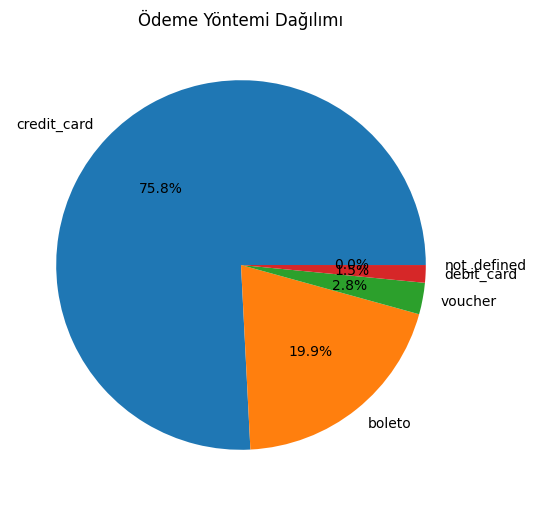

In [ ]:
plt.figure(figsize=(6,6))
order_payment_counts.plot(kind="pie", autopct="%1.1f%%")
plt.title("Ödeme Yöntemi Dağılımı")
plt.ylabel("")
plt.show()

Olist platformunda müşteriler ağırlıklı olarak kredi kartı ile ödeme tercih etmektedir.
*   Kredi kartı baskın olduğu için taksit kampanyaları ve kart bazlı
  promosyonlar artırılarak satış hacmi daha da yükseltilebilir.

*   Ödeme ekranında alternatif ödeme yöntemlerinin
  görünürlüğü artırılarak kullanıcıların farklı ödeme seçeneklerini
  tercih etmesi teşvik edilebilir.




# ***Kargo Süresi*** ***İstatistikleri***

### ***Teslimat Süresi***

Sadece teslim edilmiş siparişler üzerinden gideceğiz.

In [ ]:
delivered_orders = orders[orders['order_status']== "delivered"].copy()
delivered_orders.shape

(96478, 8)

In [ ]:
delivered_orders["delivery_time_days"] = (delivered_orders["order_delivered_customer_date"] - delivered_orders["order_purchase_timestamp"]).dt.days

In [ ]:
delivered_orders["delivery_time_days"].head()

,delivery_time_days
0,8.0
1,13.0
2,9.0
3,13.0
4,2.0


In [ ]:
delivered_orders["delivery_time_days"].describe()

,delivery_time_days
count,96470.000000
mean,12.093604
std,9.551380
min,0.000000
25%,6.000000
50%,10.000000
75%,15.000000
max,209.000000


*   Siparişlerin ortalama teslimat süresi yaklaşık **12 gün**
*   Tüm siparişlerin yarısı 10 gün içinde sahibine ulaşmış. Ortalamanın (12) medyandan (10) büyük olması, bazı çok geç giden kargoların ortalamayı yukarı çektiğini gösteriyor.
*   Standart sapma **9.5 gün**. Bu oldukça yüksek bir değer; yani kargo süreleri arasında standart bir düzen yok, süreler çok değişkebiliyor.
*   Maksimum teslimat süresi **209 gün**. Bu ciddi bir problem, bu hatalı bir giriş değilse sebebi incelenmeli.





In [ ]:
delivered_orders["delivery_time_days"].notna().sum()

np.int64(96470)

In [ ]:
delivered_orders["delivery_time_days"].isnull().sum()

np.int64(8)

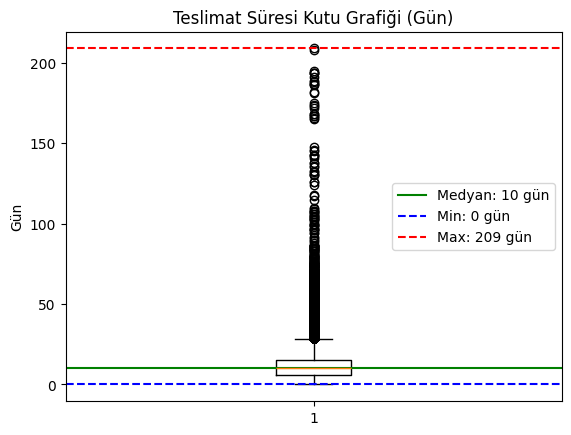

In [ ]:
from matplotlib import colors
data = delivered_orders["delivery_time_days"].dropna()

min_val = data.min()
max_val = data.max()
median_val = data.median()

plt.figure()
plt.boxplot(data)

# Medyan çizgisi (yeşil)

plt.axhline(median_val, color = "Green", linestyle = "-", label=f"Medyan: {median_val:.0f} gün")

# Minimum çizgisi (mavi)
plt.axhline(min_val, color="blue", linestyle="--", label=f"Min: {min_val:.0f} gün")

# Maksimum çizgisi (kırmızı)
plt.axhline(max_val, color="red", linestyle="--", label=f"Max: {max_val:.0f} gün")

plt.title("Teslimat Süresi Kutu Grafiği (Gün)")
plt.ylabel("Gün")
plt.legend()
plt.show()


*  Aykırı değerli siparişler analiz edilerek gecikmeye neden olan lojistik problemler tespit edilebilir.
* Teslimat performansı düşük satıcılar belirlenip kargo süreçleri optimize edilebilir veya performans bazlı değerlendirme sistemi uygulanabilir.
*  Bölgesel teslimat süreleri analiz edilerek gecikmenin yoğun olduğu bölgelerde lojistik iyileştirmeler yapılabilir.
* Teslimat süresi normal dağılımı (örneğin 15 gün üzeri) aştığında gecikme riski tespit edilerek kargo süreci hızlandırılabilir veya müşteri bilgilendirilebilir.





# ***Müşteri*** ***Memnuniyeti***

In [ ]:
reviews['review_score'].describe()

,review_score
count,99224.000000
mean,4.086421
std,1.347579
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


* Ortalama puan: 4.08 → Genel olarak müşteriler mutlu.
* Verilerin %75'sinden fazlası tam puan (5) vermiş.→ Hizmet, beklentiyi karşılıyor.
* Ancak standart sapma değeri 1,34 oldukça yüksek.





In [ ]:
# Memnun müşteriler (4 ve 5 puan)
satisfied = reviews[reviews['review_score'] >= 4]
print("Memnun müşteri sayısı:", len(satisfied))

# Memnun olmayan müşteriler (1-2-3 puan)
unsatisfied = reviews[reviews["review_score"] < 4]
print("Memnun olmayan müşteri sayısı:", len(unsatisfied))

# Memnuniyet oranı (%)
satisfaction_rate = len(satisfied) / len(reviews) * 100
print("Memnuniyet oranı(%):", round(satisfaction_rate, 2))

Memnun müşteri sayısı: 76470
Memnun olmayan müşteri sayısı: 22754
Memnuniyet oranı(%): 77.07


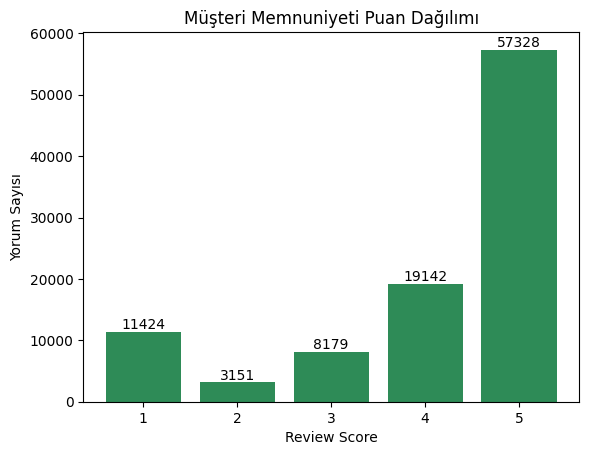

In [ ]:
score_counts = reviews["review_score"].value_counts().sort_index()

plt.figure()
bars = plt.bar(score_counts.index, score_counts.values, color="seagreen")

plt.title("Müşteri Memnuniyeti Puan Dağılımı")
plt.xlabel("Review Score")
plt.ylabel("Yorum Sayısı")

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y, int(y),
             ha='center', va='bottom')

plt.show()

5 puanlı yorumların baskın olması genel memnuniyetin yüksek olduğunu gösterirken, 1 puanlı yorumun bulunması teslimat süresi, ürün kalitesi veya lojistik süreçlerde yaşanan sorunlara işaret edebilir.

### **☹ Memnuniyetsizlik Sebepleri**
*   Geç teslimat
*   Ürün beklentiyi karşılamaması
*   Hasarlı / eksik ürün
*   Satıcı veya müşteri hizmetleri problemi


# ***🚚 Kargo Süresi vs ⭐ Müşteri Memnuniyeti***

## ***🧪Hipotez Testi***

Teslimat süresi memnuniyeti etkiler mi?

H0: Teslimat süresi memnuniyeti etkilemez.

H1: Uzun teslimat süresi daha düşük memnuniyet oluşturur.

In [ ]:
analysis_df = delivered_orders.merge(reviews[['order_id','review_score']], on='order_id', how="inner")

In [ ]:
analysis_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time_days,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,4
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,4
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,5
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,5
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0,5


Teslimatlar **medyan** değeri kullanılarak 2 gruba ayrılacak;
*   Grup A: Hızlı teslimat (<=medyan)
*   Grup B: Yavaş teslimat (>medyan)


In [ ]:
median_delivery = analysis_df["delivery_time_days"].median()
median_delivery

10.0

In [ ]:
fast_delivery = analysis_df[analysis_df['delivery_time_days']<=10]
slow_delivery = analysis_df[analysis_df['delivery_time_days']>10]

In [ ]:
print("Hızlı teslimat sayısı:", fast_delivery.shape[0])
print("Yavaş teslimat sayısı:", slow_delivery.shape[0])

Hızlı teslimat sayısı: 52079
Yavaş teslimat sayısı: 44274


*Hızlı gelen siparişler daha yüksek puan mı almış?*

In [ ]:
fast_mean = fast_delivery['review_score'].mean()
slow_mean = slow_delivery['review_score'].mean()


print("Hızlı teslimat ortalama memnuniyet:", round(fast_mean, 2))
print("Yavaş teslimat ortalama memnuniyet:", round(slow_mean, 2))

Hızlı teslimat ortalama memnuniyet: 4.38
Yavaş teslimat ortalama memnuniyet: 3.89


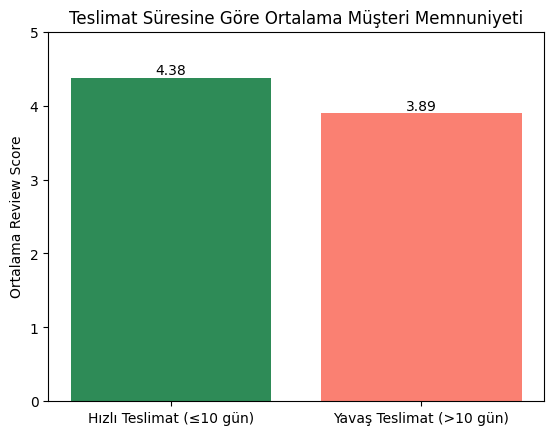

In [ ]:
labels = ["Hızlı Teslimat (≤10 gün)", "Yavaş Teslimat (>10 gün)"]
means = [fast_mean, slow_mean]

plt.figure()
bars = plt.bar(labels, means, color=["seagreen", "salmon"])

plt.title("Teslimat Süresine Göre Ortalama Müşteri Memnuniyeti")
plt.ylabel("Ortalama Review Score")

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y,
        round(y, 2),
        ha='center',
        va='bottom'
    )

plt.ylim(0, 5)
plt.show()

Ortalama memnuniyetler arasındaki fark = **0.49**

Hızlı teslim edilen siparişlerdeki memnuniyet daha yüksektir. (***H1 Hipotezini destekler.***)

Bu fark gerçekten anlamlı mı şans eseri mi? → ***T-Test yapılmalı.***

In [ ]:
from scipy.stats import ttest_ind

In [ ]:
t_stat, p_value = ttest_ind(
    fast_delivery["review_score"],
    slow_delivery["review_score"],
    equal_var=False
)

print("T-istatistiği:", round(t_stat, 3))
print("P-değeri:", p_value)

T-istatistiği: 58.181
P-değeri: 0.0



*   P-değeri 0.05’ten çok küçük, H0 hipotezi reddedilmiştir.
*   T-istatistiği çok yüksek.

✔  ***H1 hipotezi kabul edilir.***

Sonuç olarak teslimat süresinin müşteri memnuniyeti üzerinde istatistiksel olarak anlamlı bir etkisi olduğu görülmüştür.


✅ ***KPI*** olarak ***"10 Gün Altında Teslimat Oranı"*** belirlenebilir. Bu KPI'nın takip edilmesi müşteri memnuniyetini artırmaya yönelik kararlar alınmasını sağlayacaktır.

## 🚀***İyileştirme Önerileri;***


*   10 gün üzeri teslimat riski olan siparişler için erken uyarı
  ve önceliklendirme sistemi kurulabilir.

*   Müşterilerin sipariş ve teslimat süreçleri hakkında anlık bilgi alabilmesi için AI tabanlı bir müşteri destek asistanı geliştirilebilir, eğer varsa daha da geliştirilebilir.

*   Yine AI tabanlı bir modelle geçmiş sipariş, mesafe ve lojistik veriler kullanılarak daha doğru bir tahmini teslimat süresi hesaplanabilir.

*   Teslimat süresi uzayan müşterilerdeki memnuniyetin düşmesini engellemek için indirim kuponu, hediye veya puan vermek gibi telafi edici aksiyonlar uygulanabilir.

*   Teslimat süresi tahmin edilenden fazla olan müşterilerden kargo ücreti alınmayabilir.

